In [1]:
# Environment check (optional)
import sys, platform
import numpy as np, sklearn, torch, torchvision, PIL, tqdm
print("Python:", sys.version.split()[0])
print("OS:", platform.platform())
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("PyTorch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
print("Torchvision:", torchvision.__version__)
print("Pillow:", PIL.__version__)

Python: 3.12.7
OS: Windows-11-10.0.26200-SP0
NumPy: 2.3.5
scikit-learn: 1.7.2
PyTorch: 2.5.1+cu121 | CUDA available: True
Torchvision: 0.20.1+cu121
Pillow: 12.0.0


In [2]:
# Reproducibility
import os, random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
import os, ssl, hashlib, zipfile, io
from pathlib import Path
import urllib.request
import torchvision
from torchvision import transforms

CUSTOM_CA_PEM = os.environ.get("SSL_CERT_FILE", "")
ALLOW_INSECURE_DOWNLOAD = False
EUROSAT_URL = "https://madm.dfki.de/files/sentinel/EuroSAT.zip"
EUROSAT_MD5 = "c8fa014336c82ac7804f0398fcb19387"

def _enable_ca_bundle(ca_pem):
    if not ca_pem or not Path(ca_pem).exists():
        return False
    os.environ["SSL_CERT_FILE"] = ca_pem
    os.environ["REQUESTS_CA_BUNDLE"] = ca_pem
    try:
        ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=ca_pem)
        print("[EuroSAT] Using CA bundle:", ca_pem)
        return True
    except Exception as e:
        print("[EuroSAT] Could not apply CA bundle:", e)
        return False

def _md5_bytes(b):
    m = hashlib.md5(); m.update(b); return m.hexdigest()

def _manual_download_zip(url, ca_pem=None, allow_insecure=False):
    ctx = None
    if ca_pem and Path(ca_pem).exists():
        ctx = ssl.create_default_context(cafile=ca_pem)
    elif allow_insecure:
        print("[EuroSAT] WARNING: insecure download (TLS verification disabled).")
        ctx = ssl._create_unverified_context()
    with urllib.request.urlopen(url, context=ctx) as r:
        data = r.read()
    md5 = _md5_bytes(data)
    if md5 != EUROSAT_MD5:
        raise RuntimeError(f"EuroSAT.zip MD5 mismatch: got {md5}, expected {EUROSAT_MD5}")
    return data

def load_eurosat_with_fallback(root, transform_train, transform_eval):
    root = Path(root)
    try:
        if CUSTOM_CA_PEM:
            _enable_ca_bundle(CUSTOM_CA_PEM)
        ds = torchvision.datasets.EuroSAT(root=str(root), download=True, transform=transform_train)
        return ds, ds.classes
    except Exception as e:
        print("[EuroSAT] torchvision download failed:", repr(e))
        local_dir = root / "eurosat" / "2750"
        if local_dir.is_dir():
            print("[EuroSAT] Found local directory:", local_dir, "— using ImageFolder.")
            ds = torchvision.datasets.ImageFolder(str(local_dir), transform=transform_train)
            return ds, ds.classes
        if ALLOW_INSECURE_DOWNLOAD or (CUSTOM_CA_PEM and Path(CUSTOM_CA_PEM).exists()):
            print("[EuroSAT] Attempting manual download with MD5 verification...")
            data = _manual_download_zip(EUROSAT_URL, ca_pem=CUSTOM_CA_PEM, allow_insecure=ALLOW_INSECURE_DOWNLOAD)
            base = root / "eurosat"; base.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(io.BytesIO(data)) as zf:
                zf.extractall(base)
            local_dir = base / "2750"
            if local_dir.is_dir():
                print("[EuroSAT] Manual download ok. Using ImageFolder.")
                ds = torchvision.datasets.ImageFolder(str(local_dir), transform=transform_train)
                return ds, ds.classes
        raise RuntimeError("EuroSAT unavailable. Provide CA bundle, enable ALLOW_INSECURE_DOWNLOAD=True, or place './data/eurosat/2750'.")

### Data Pipeline and Loaders

In [ ]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
import torch

import copy

data_root = "./data"

transform_eval = None  

transform_eval = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_full, classes = load_eurosat_with_fallback(data_root, transform_eval, transform_eval)
num_classes = len(classes)
print(f"Classes: {classes}")
print(f"Total images: {len(train_full)}")

total_size = len(train_full)
train_size = int(0.6 * total_size)
val_size = int(0.2 * total_size)
test_size = total_size - train_size - val_size

generator = torch.Generator().manual_seed(42)
train_ds, val_ds, test_ds = random_split(train_full, [train_size, val_size, test_size], generator=generator)

print(f"Splits: Train {len(train_ds)}, Val {len(val_ds)}, Test {len(test_ds)}")


def make_loaders(batch=128, train_transform=None):
    """Create DataLoaders for train/val/test.

    - If train_transform is not None, it should be used for the training subset only.
    - Validation and test subsets should always use transform_eval.
    """

    if train_transform is not None:
        train_ds_final = copy.deepcopy(train_ds)
        train_ds_final.dataset.transform = train_transform
    else:
        train_ds_final = train_ds

    loader_train = DataLoader(train_ds_final, batch_size=batch, shuffle=True, num_workers=2, pin_memory=True)
    loader_val = DataLoader(val_ds, batch_size=batch, shuffle=False, num_workers=2, pin_memory=True)
    loader_test = DataLoader(test_ds, batch_size=batch, shuffle=False, num_workers=2, pin_memory=True)
    
    return loader_train, loader_val, loader_test

Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total images: 27000
Splits: Train 16200, Val 5400, Test 5400


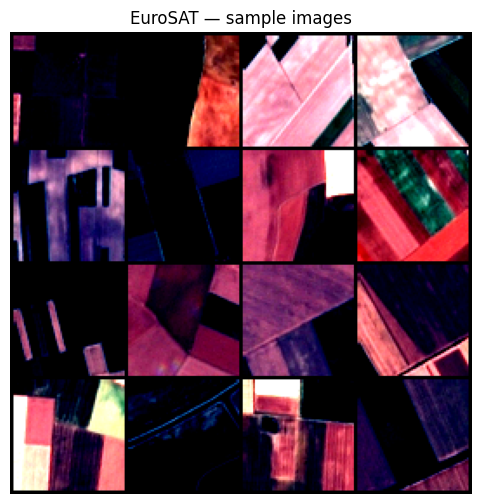

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torchvision

try:
    assert 'train_full' in globals() and 'classes' in globals(), "Run first to define 'train_full' and 'classes'"
    idxs = list(range(min(16, len(train_full))))
    imgs = [train_full[i][0] for i in idxs]
    ys   = [train_full[i][1] for i in idxs]
    grid = torchvision.utils.make_grid(torch.stack(imgs), nrow=4)
    npimg = grid.numpy().transpose(1,2,0)
    plt.figure(figsize=(6,6)); plt.imshow(np.clip(npimg,0,1)); plt.axis('off')
    plt.title("EuroSAT — sample images")
    plt.show()
    
except Exception as e:
    print("Sample gallery unavailable until B1 is implemented.", e)

In [ ]:
try:
    train_loader, val_loader, test_loader = make_loaders(batch=128)
    xb, yb = next(iter(train_loader))
    assert xb.ndim == 4 and xb.shape[1] == 3 and xb.shape[2] == 64 and xb.shape[3] == 64
    assert yb.ndim == 1 and yb.dtype == torch.long
    print("✓ Data loader sanity checks passed.")

except NotImplementedError:
    print("Implement make_loaders properly first to run this check.")
    
except AssertionError as e:
    print("Sanity check failed:", e)


✓ Data loader sanity checks passed.


### CNN Architectures

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CNN_A(nn.Module):
    """Baseline CNN with two conv blocks and a small MLP classifier.

    Input:  [B, 3, 64, 64]
    Output: [B, num_classes] logits
    """
    
    def __init__(self, num_classes):
        super().__init__()

        # Block 1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        # Flatten calculation
        self.fc1 = nn.Linear(32 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        
        # Block 2
        x = self.pool(F.relu(self.conv2(x)))
        
        # Flatten
        x = x.view(x.size(0), -1)  
        
        # Head
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

class CNN_B(nn.Module):
    """Improved CNN (deeper/wider and possibly with dropout) than CNN_A."""
    
    def __init__(self, num_classes):
        super().__init__()
        
        # Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        # Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
                
        self.fc1 = nn.Linear(128 * 8 * 8, 512) 
        self.dropout = nn.Dropout(0.5)         
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        
        # Block 2
        x = self.pool(F.relu(self.conv2(x)))
        
        # Block 3
        x = self.pool(F.relu(self.conv3(x)))
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Head with Dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

In [ ]:
import torch

try:
    mA = CNN_A(num_classes).to(device)
    mB = CNN_B(num_classes).to(device)
    train_loader, _, _ = make_loaders(batch=8)
    xb, yb = next(iter(train_loader))
    xb = xb.to(device)
    logitsA = mA(xb); logitsB = mB(xb)
    assert logitsA.shape == (xb.size(0), num_classes), f"CNN_A logits must be [B, C], got {logitsA.shape}"
    assert logitsB.shape == (xb.size(0), num_classes), f"CNN_B logits must be [B, C], got {logitsB.shape}"
    print("✓ CNN_A/CNN_B forward shape checks passed.")

except NotImplementedError:
    print("Implement models and loaders first to run this check.")

except Exception as e:
    print("Model forward shape check failed:", e)


✓ CNN_A/CNN_B forward shape checks passed.


### Optimizers, Learning-rate Schedulers, Training Loop, and Hyperparamter Tuning

In [ ]:
from collections import defaultdict
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def make_optimizer(model, opt_name="adam", lr=1e-3, weight_decay=0.0, momentum=0.9):
    """B3: create an optimizer for model parameters.

    Supported opt_name values:
    - "adam": Adam optimizer
    - "sgd" : SGD with momentum
    """
    params = model.parameters()
    
    if opt_name.lower() == "adam":
        return optim.Adam(params, lr=lr, weight_decay=weight_decay)
    elif opt_name.lower() == "sgd":
        return optim.SGD(params, lr=lr, momentum=momentum, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unknown optimizer: {opt_name}")

def make_scheduler(optimizer, sched_name="none", epochs=20, step_size=10, gamma=0.1):
    """B3: create a learning-rate scheduler.

    Supported sched_name values:
    - "none"  :  no scheduler (returns None)
    - "cosine": CosineAnnealingLR over the given number of epochs
    - "step"  : StepLR with provided step_size and gamma
    """
    if sched_name.lower() == "none":
        return None
    elif sched_name.lower() == "cosine":
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    elif sched_name.lower() == "step":
        return optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
    else:
        raise ValueError(f"Unknown scheduler: {sched_name}")

def train_one_model(
    model,
    train_loader,
    val_loader,
    epochs=20,
    opt_cfg=None,
    sched_name="none",
    patience=5,
):
    """B3: standard supervised training loop with optional LR scheduler
    and early stopping.

    Returns the (possibly early-stopped) model and a history dict with
    keys such as "train_loss", "val_loss", "train_acc", "val_acc".
    """

    if opt_cfg is None: opt_cfg = {}
    
    model = model.to(device)
    optimizer = make_optimizer(model, **opt_cfg)
    scheduler = make_scheduler(optimizer, sched_name, epochs=epochs)
    criterion = nn.CrossEntropyLoss()
    
    hist = defaultdict(list)
    best_val_loss = float('inf')
    patience_counter = 0
    
    print(f"Starting training on {device}...")
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            # Zero gradients
            optimizer.zero_grad()
            
            # Forward
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            # Backward
            loss.backward()
            optimizer.step()
            
            # Metrics
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total
        
        model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                
                val_loss_sum += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += targets.size(0)
                val_correct += predicted.eq(targets).sum().item()
        
        epoch_val_loss = val_loss_sum / val_total
        epoch_val_acc = val_correct / val_total
        
        hist['train_loss'].append(epoch_train_loss)
        hist['val_loss'].append(epoch_val_loss)
        hist['train_acc'].append(epoch_train_acc)
        hist['val_acc'].append(epoch_val_acc)
        
        if scheduler is not None:
            scheduler.step()
            
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
                
    return model, hist

In [ ]:
try:
    train_loader, val_loader, test_loader = make_loaders(batch=64)
    model = CNN_A(num_classes).to(device)
    model, hist = train_one_model(
        model,
        train_loader,
        val_loader,
        epochs=2,
        opt_cfg={"opt_name": "adam", "lr": 1e-3, "weight_decay": 0.0, "momentum": 0.9},
        sched_name="cosine",
        patience=1,
    )
    assert "val_loss" in hist and len(hist["val_loss"]) > 0, "val_loss must be tracked"
    print("✓ Training loop sanity check passed (short run).")
    
except Exception as e:
    print("Training loop sanity check failed:", e)


Starting training on cuda...
✓ Training loop sanity check passed (short run).


In [ ]:
B_HPARAMS = {
    "model": "CNN_A",     
    "opt_name": "adam",
    "lr": 1e-3,
    "weight_decay": 5e-4,
    "sched_name": "cosine",
    "epochs": 12,
    "batch": 128,
    "momentum": 0.9,
}
print("Base B_HPARAMS:", B_HPARAMS)

B_GRID = {
    "model": ["CNN_A", "CNN_B"],
    "opt_name": ["adam", "sgd"],
    "lr": [5e-4, 1e-3, 5e-3],
    "weight_decay": [0.0, 5e-4],
    "sched_name": ["cosine", "step"],
}

print("Example B_GRID keys:", list(B_GRID.keys()))

Base B_HPARAMS: {'model': 'CNN_A', 'opt_name': 'adam', 'lr': 0.001, 'weight_decay': 0.0005, 'sched_name': 'cosine', 'epochs': 12, 'batch': 128, 'momentum': 0.9}
Example B_GRID keys: ['model', 'opt_name', 'lr', 'weight_decay', 'sched_name']


In [ ]:
import pandas as pd, time

def evaluate_on(loader, model):
    model.eval()
    correct = 0
    n = 0
    loss_sum = 0.0
    
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            loss_sum += loss.item() * xb.size(0)
            n += xb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
    return {"loss": loss_sum / max(1, n), "acc": correct / max(1, n)}

def build_model(model_name, num_classes):
    if model_name == "CNN_A":
        return CNN_A(num_classes)
    elif model_name == "CNN_B":
        return CNN_B(num_classes)
    else:
        raise ValueError(f"Unknown model_name={model_name}")

def run_experiment(
    model_name="CNN_A",
    train_transform=None,
    opt_name="adam",
    lr=1e-3,
    weight_decay=0.0,
    sched_name="none",
    epochs=12,
    batch=128,
    momentum=0.9,
):
    """Single training run for one configuration.

    Returns a dictionary with at least:
      - "val_acc" and "test_acc"
      - the configuration (model_name, opt_name, lr, weight_decay, sched_name, etc.).
    """

    train_loader, val_loader, test_loader = make_loaders(batch=batch, train_transform=train_transform)
    num_classes = 10 

    # Build
    model = build_model(model_name, num_classes)
    
    # Train
    opt_cfg = {
        "opt_name": opt_name, 
        "lr": lr, 
        "weight_decay": weight_decay, 
        "momentum": momentum
    }
    
    start_time = time.time()
    model, hist = train_one_model(
        model,
        train_loader,
        val_loader,
        epochs=epochs,
        opt_cfg=opt_cfg,
        sched_name=sched_name,
        patience=5
    )
    duration = time.time() - start_time
    
    # Evaluate
    val_metrics = evaluate_on(val_loader, model)
    test_metrics = evaluate_on(test_loader, model)
    
    return {
        "model": model_name,
        "opt_name": opt_name,
        "lr": lr,
        "wd": weight_decay,
        "sched": sched_name,
        "val_acc": val_metrics["acc"],
        "test_acc": test_metrics["acc"],
        "duration": round(duration, 1)
    }

print("Base B_HPARAMS:", B_HPARAMS)
print("Example B_GRID keys:", list(B_GRID.keys()))

configs = [

    # Baseline
    {"model_name": "CNN_A", "opt_name": "adam", "lr": 1e-3, "weight_decay": 0.0},

    # Baseline SGD
    {"model_name": "CNN_A", "opt_name": "sgd",  "lr": 1e-2, "weight_decay": 0.0},

    # Model B
    {"model_name": "CNN_B", "opt_name": "adam", "lr": 1e-3, "weight_decay": 0.0},

    # Model B + Regularization
    {"model_name": "CNN_B", "opt_name": "adam", "lr": 1e-3, "weight_decay": 1e-4},

    # Model B + Scheduler
    {"model_name": "CNN_B", "opt_name": "adam", "lr": 1e-3, "sched_name": "cosine"},
    
    # Model B + High LR
    {"model_name": "CNN_B", "opt_name": "adam", "lr": 5e-3, "sched_name": "cosine"},
]

results = []
for i, cfg in enumerate(configs):
    print(f"\nExperiment {i+1}/{len(configs)}: {cfg}")
    res = run_experiment(**cfg)
    results.append(res)
    print(f"  ---> Val Acc: {res['val_acc']:.4f}")

df = pd.DataFrame(results)
df = df.sort_values(by="val_acc", ascending=False)

print("\nHyperparameter Tuning Results")
print(df.to_string())

Base B_HPARAMS: {'model': 'CNN_A', 'opt_name': 'adam', 'lr': 0.001, 'weight_decay': 0.0005, 'sched_name': 'cosine', 'epochs': 12, 'batch': 128, 'momentum': 0.9}
Example B_GRID keys: ['model', 'opt_name', 'lr', 'weight_decay', 'sched_name']

Experiment 1/6: {'model_name': 'CNN_A', 'opt_name': 'adam', 'lr': 0.001, 'weight_decay': 0.0}
Starting training on cuda...
  ---> Val Acc: 0.8011

Experiment 2/6: {'model_name': 'CNN_A', 'opt_name': 'sgd', 'lr': 0.01, 'weight_decay': 0.0}
Starting training on cuda...
  ---> Val Acc: 0.8150

Experiment 3/6: {'model_name': 'CNN_B', 'opt_name': 'adam', 'lr': 0.001, 'weight_decay': 0.0}
Starting training on cuda...
  ---> Val Acc: 0.8954

Experiment 4/6: {'model_name': 'CNN_B', 'opt_name': 'adam', 'lr': 0.001, 'weight_decay': 0.0001}
Starting training on cuda...
  ---> Val Acc: 0.9033

Experiment 5/6: {'model_name': 'CNN_B', 'opt_name': 'adam', 'lr': 0.001, 'sched_name': 'cosine'}
Starting training on cuda...
  ---> Val Acc: 0.8998

Experiment 6/6: {'mo

### Data Augmentation Design and Experiments

In [ ]:
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import torch

AUG_POLICIES = {

    # Flips
    "flip": transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
    ]),
    
    # Geometric
    "geo": transforms.Compose([
        transforms.RandomRotation(degrees=30),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    ]),
    
    # Color
    "color": transforms.Compose([
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    ]),
    
    # Strong
    "strong": transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=45),
        transforms.RandomResizedCrop(size=64, scale=(0.8, 1.0), ratio=(0.9, 1.1))
    ])
}


def make_aug_transform(name):
    """Build the training-time transform for a given augmentation policy.

    This transform is intended to be passed as the `train_transform` argument
    to `make_loaders(...)` in B1 for training models with data augmentation.
    """
    
    if name not in AUG_POLICIES:
        raise ValueError(f"Unknown augmentation policy: {name}")
    aug = AUG_POLICIES[name]
    return transforms.Compose([aug, transform_eval])

def show_augmented_batch(policy_names, batch_size=32, max_images=16):
    """Visualize how augmentation policies modify the *same* batch of images.

    The function resets the random seed before constructing each DataLoader
    so that the same subset of training examples is used for every policy.
    This makes the visual comparison across policies much easier.
    """
    
    if isinstance(policy_names, str):
        policy_names = [policy_names]

    import math
    n_show = min(batch_size, max_images)

    for name in policy_names:

        # Use the same underlying batch across policies by reseeding
        torch.manual_seed(0)
        train_loader, _, _ = make_loaders(
            batch=batch_size,
            train_transform=make_aug_transform(name),
        )
        xb, yb = next(iter(train_loader)) 

        # Move to CPU for np and pd and plt
        xb_cpu = xb.detach().cpu()
        grid = torchvision.utils.make_grid(
            xb_cpu[:n_show],
            nrow=int(math.sqrt(n_show)),
        )
        img = grid.numpy().transpose(1, 2, 0)
        img = np.clip(img, 0.0, 1.0)

        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Augmentation: {name}")
        plt.show()

base_config = {
    "model_name": "CNN_B",
    "opt_name": "adam",
    "lr": 1e-3,
    "weight_decay": 0.0,
    "sched_name": "cosine",
    "epochs": 15,  
    "batch": 128
}

aug_experiments = ["baseline", "flip", "geo", "color", "strong"]
aug_results = []

for policy in aug_experiments:
    print(f"\nTesting Policy: {policy}")
    
    if policy == "baseline":
        train_tf = None 
        train_tf = None 
    else:
        train_tf = make_aug_transform(policy)
    
    res = run_experiment(
        train_transform=train_tf,
        **base_config
    )
    
    res["aug_policy"] = policy
    aug_results.append(res)
    print(f"  -> Val Acc: {res['val_acc']:.4f} | Test Acc: {res['test_acc']:.4f}")

df_aug = pd.DataFrame(aug_results)
df_aug = df_aug[["aug_policy", "val_acc", "test_acc", "duration"]]
df_aug = df_aug.sort_values(by="val_acc", ascending=False)

print("\nAugmentation Experiment Results")
print(df_aug.to_string())


Testing Policy: baseline
Starting training on cuda...
  -> Val Acc: 0.9111 | Test Acc: 0.9046

Testing Policy: flip
Starting training on cuda...
  -> Val Acc: 0.9226 | Test Acc: 0.9167

Testing Policy: geo
Starting training on cuda...
  -> Val Acc: 0.9143 | Test Acc: 0.9143

Testing Policy: color
Starting training on cuda...
  -> Val Acc: 0.8724 | Test Acc: 0.8781

Testing Policy: strong
Starting training on cuda...
  -> Val Acc: 0.8606 | Test Acc: 0.8528

Augmentation Experiment Results
  aug_policy   val_acc  test_acc  duration
1       flip  0.922593  0.916667     151.6
2        geo  0.914259  0.914259     157.8
0   baseline  0.911111  0.904630     148.0
3      color  0.872407  0.878148     181.3
4     strong  0.860556  0.852778     172.7
